# NBA Draft Success - Exploratory Data Analysis
### Data Sources
- **draft_history** — draft picks from 2000 onwards (round, pick, team, school)
- **draft_combine_stats** — physical & athletic measurements (wingspan, vertical, agility) — 2000 onwards, bench press excluded
- **common_player_info** — career info (seasons played, position, active status)

### Goal
Understand the structure, quality, and distributions of each dataset before building a model to predict draft success.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = r"E:\Github\PS-Acq-Claude-Code-Test\jeff-NBA-model\nba.sqlite"
conn = sqlite3.connect(DB_PATH)
print("Connected to database")

Connected to database


## 1. Draft History

In [2]:
draft = pd.read_sql_query("SELECT * FROM draft_history WHERE season >= 2000", conn)
print(f"Rows: {len(draft)}")
print(f"Columns: {draft.shape[1]}")
print(f"Year range: {draft['season'].min()} - {draft['season'].max()}")
draft.dtypes

Rows: 1425
Columns: 14
Year range: 2000 - 2023


person_id              object
player_name            object
season                 object
round_number            int64
round_pick              int64
overall_pick            int64
draft_type             object
team_id                object
team_city              object
team_name              object
team_abbreviation      object
organization           object
organization_type      object
player_profile_flag    object
dtype: object

In [3]:
print("Missing values:")
draft.isnull().sum()

Missing values:


person_id              0
player_name            0
season                 0
round_number           0
round_pick             0
overall_pick           0
draft_type             0
team_id                0
team_city              0
team_name              0
team_abbreviation      0
organization           0
organization_type      0
player_profile_flag    0
dtype: int64

In [4]:
draft.describe()

,round_number,round_pick,overall_pick
count,1425.000000,1425.000000,1425.000000
mean,1.499649,15.350175,30.196491
std,0.500175,8.579039,17.159017
min,1.000000,1.000000,1.000000
25%,1.000000,8.000000,15.000000
50%,1.000000,15.000000,30.000000
75%,2.000000,23.000000,45.000000
max,2.000000,30.000000,60.000000


In [5]:
draft.head(10)

,person_id,player_name,season,round_number,round_pick,overall_pick,draft_type,team_id,team_city,team_name,team_abbreviation,organization,organization_type,player_profile_flag
0,2030,Kenyon Martin,2000,1,1,1,Draft,1610612751,New Jersey,Nets,NJN,Cincinnati,College/University,1
1,2031,Stromile Swift,2000,1,2,2,Draft,1610612763,Vancouver,Grizzlies,VAN,Louisiana State,College/University,1
2,2032,Darius Miles,2000,1,3,3,Draft,1610612746,Los Angeles,Clippers,LAC,East St. Louis,High School,1
3,2033,Marcus Fizer,2000,1,4,4,Draft,1610612741,Chicago,Bulls,CHI,Iowa State,College/University,1
4,2034,Mike Miller,2000,1,5,5,Draft,1610612753,Orlando,Magic,ORL,Florida,College/University,1
5,2035,DerMarr Johnson,2000,1,6,6,Draft,1610612737,Atlanta,Hawks,ATL,Cincinnati,College/University,1
6,2036,Chris Mihm,2000,1,7,7,Draft,1610612741,Chicago,Bulls,CHI,Texas,College/University,1
7,2037,Jamal Crawford,2000,1,8,8,Draft,1610612739,Cleveland,Cavaliers,CLE,Michigan,College/University,1
8,2038,Joel Przybilla,2000,1,9,9,Draft,1610612745,Houston,Rockets,HOU,Minnesota,College/University,1
9,2039,Keyon Dooling,2000,1,10,10,Draft,1610612753,Orlando,Magic,ORL,Missouri,College/University,1


## 2. Draft Combine Stats

In [6]:
combine_cols = [
    'season', 'player_id', 'player_name', 'position',
    'height_wo_shoes', 'weight', 'wingspan', 'standing_reach',
    'standing_vertical_leap', 'max_vertical_leap',
    'lane_agility_time', 'modified_lane_agility_time', 'three_quarter_sprint'
]

combine = pd.read_sql_query(
    f"SELECT {', '.join(combine_cols)} FROM draft_combine_stats WHERE season >= 2000", conn
)
print(f"Rows: {len(combine)}")
print(f"Columns: {combine.shape[1]}")
print(f"Year range: {combine['season'].min()} - {combine['season'].max()}")
combine.dtypes

Rows: 1633
Columns: 13
Year range: 2000 - 2023


season                         object
player_id                      object
player_name                    object
position                       object
height_wo_shoes               float64
weight                         object
wingspan                      float64
standing_reach                float64
standing_vertical_leap        float64
max_vertical_leap             float64
lane_agility_time             float64
modified_lane_agility_time    float64
three_quarter_sprint          float64
dtype: object

In [7]:
print("Missing values (%):")
missing = (combine.isnull().sum() / len(combine) * 100).round(1)
print(missing[missing > 0])

Missing values (%):
height_wo_shoes                3.6
weight                         3.6
wingspan                       3.6
standing_reach                 3.6
standing_vertical_leap        14.5
max_vertical_leap             14.5
lane_agility_time             15.1
modified_lane_agility_time    68.8
three_quarter_sprint          15.1
dtype: float64


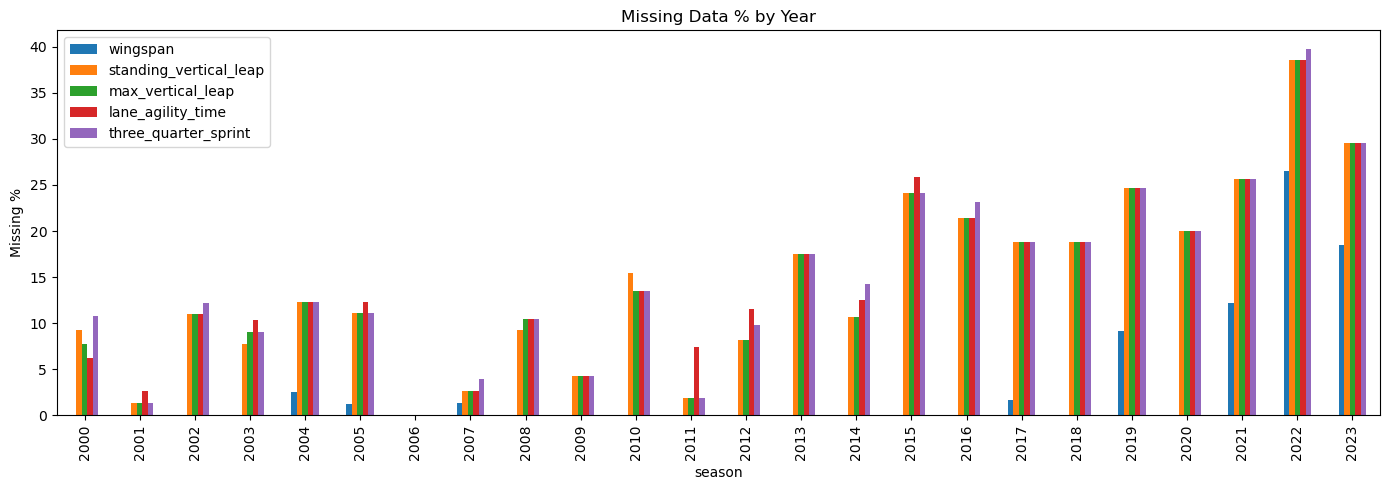

In [8]:
# Missing values by year for key metrics
key_metrics = ['wingspan', 'standing_vertical_leap', 'max_vertical_leap', 'lane_agility_time', 'three_quarter_sprint']
missing_by_year = combine.groupby('season')[key_metrics].apply(lambda x: x.isnull().mean() * 100).round(1)
missing_by_year.plot(kind='bar', figsize=(14, 5), title='Missing Data % by Year')
plt.ylabel('Missing %')
plt.tight_layout()
plt.show()

In [9]:
combine.describe()

,height_wo_shoes,wingspan,standing_reach,standing_vertical_leap,max_vertical_leap,lane_agility_time,modified_lane_agility_time,three_quarter_sprint
count,1575.000000,1575.000000,1574.00000,1396.000000,1396.000000,1387.000000,509.000000,1387.000000
mean,77.600444,82.402286,103.50899,29.254835,34.521490,11.413857,3.088173,3.280497
std,3.356327,4.006972,4.87840,3.099532,3.704144,0.598113,0.220015,0.133918
min,67.750000,70.000000,88.50000,19.500000,21.000000,9.650000,2.220000,2.910000
25%,75.250000,79.750000,100.00000,27.000000,32.000000,10.990000,2.980000,3.190000
50%,77.750000,82.500000,104.00000,29.000000,34.500000,11.350000,3.100000,3.270000
75%,80.125000,85.250000,107.00000,31.500000,37.000000,11.750000,3.230000,3.360000
max,89.250000,98.250000,122.50000,41.500000,48.000000,14.450000,3.760000,3.810000


In [10]:
combine.head(10)

,season,player_id,player_name,position,height_wo_shoes,weight,wingspan,standing_reach,standing_vertical_leap,max_vertical_leap,lane_agility_time,modified_lane_agility_time,three_quarter_sprint
0,2000,2124,Malik Allen,PF-C,80.25,271,86.50,109.0,25.5,29.0,11.83,NaN,3.38
1,2000,12019,Harold Arceneaux,SG-SF,76.50,219,80.50,103.0,NaN,29.0,13.80,NaN,NaN
2,2000,12020,Lamont Barnes,PF-C,80.50,235.5,87.50,108.0,28.0,29.5,12.30,NaN,3.40
3,2000,12131,Mario Bland,PF,77.50,287,84.00,103.0,27.0,31.0,13.04,NaN,3.47
4,2000,2056,Primoz Brezec,C,84.75,243,86.00,110.0,26.0,29.5,11.53,NaN,3.55
5,2000,2081,Ernest Brown,C,82.00,222.5,85.25,109.5,NaN,NaN,NaN,NaN,NaN
6,2000,2049,Speedy Claxton,PG,70.50,166,72.00,94.5,36.0,42.5,10.48,NaN,3.06
7,2000,12132,Eric Coley,SG-SF,76.00,205,83.00,102.0,35.0,38.0,11.40,NaN,3.15
8,2000,12133,Ed Cota,PG,72.25,189,76.00,96.5,26.5,33.5,10.98,NaN,3.24
9,2000,12134,Schea Cotton,SF,76.25,219.5,79.00,100.0,34.0,38.0,11.55,NaN,3.00


## 3. Player Career Info

In [11]:
players = pd.read_sql_query("""
    SELECT person_id, display_first_last, position, height, weight,
           season_exp, from_year, to_year,
           draft_year, draft_round, draft_number,
           country, school, greatest_75_flag
    FROM common_player_info
    WHERE draft_year >= 2000
""", conn)
print(f"Rows: {len(players)}")
print(f"Columns: {players.shape[1]}")
players.dtypes

Rows: 1876
Columns: 14


person_id              object
display_first_last     object
position               object
height                 object
weight                 object
season_exp            float64
from_year             float64
to_year               float64
draft_year             object
draft_round            object
draft_number           object
country                object
school                 object
greatest_75_flag       object
dtype: object

In [12]:
print("Missing values (%):")
missing = (players.isnull().sum() / len(players) * 100).round(1)
print(missing[missing > 0])

Missing values (%):
draft_round     2.1
draft_number    2.2
country         0.1
school          0.1
dtype: float64


In [13]:
players.describe(include='all')

,person_id,display_first_last,position,height,weight,season_exp,from_year,to_year,draft_year,draft_round,draft_number,country,school,greatest_75_flag
count,1876,1876,1876,1876,1876,1876.000000,1876.000000,1876.000000,1876,1837,1835,1875,1875,1876
unique,1876,1872,8,25,126,NaN,NaN,NaN,24,4,62,65,473,2
top,76007,Chris Wright,Guard,6-5,200,NaN,NaN,NaN,Undrafted,Undrafted,Undrafted,USA,Kentucky,N
freq,1,2,737,191,103,NaN,NaN,NaN,931,931,931,1552,54,1865
mean,NaN,NaN,NaN,NaN,NaN,4.558102,2001.220682,2004.978678,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,3.925212,23.145990,24.051690,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,1946.000000,1946.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,2.000000,2000.000000,2002.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,3.000000,2009.000000,2015.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,6.000000,2017.000000,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN


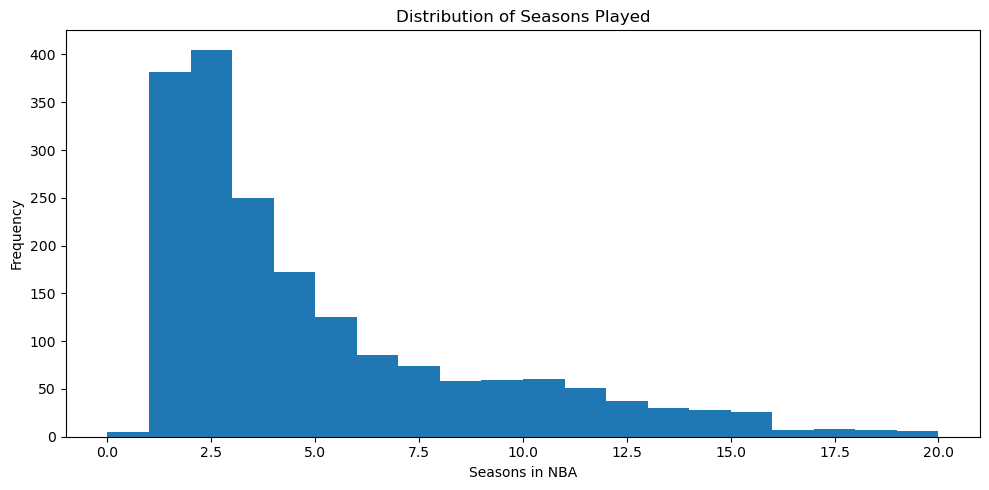

In [14]:
# Distribution of seasons played
players['season_exp'].dropna().plot(kind='hist', bins=20, figsize=(10, 5), title='Distribution of Seasons Played')
plt.xlabel('Seasons in NBA')
plt.tight_layout()
plt.show()

In [15]:
players.head(10)

,person_id,display_first_last,position,height,weight,season_exp,from_year,to_year,draft_year,draft_round,draft_number,country,school,greatest_75_flag
0,76007,John Abramovic,Forward,6-3,195,2.0,1946.0,1947.0,Undrafted,Undrafted,Undrafted,USA,Salem,N
1,203518,Alex Abrines,Guard,6-6,200,3.0,2016.0,2018.0,2013,2,32,Spain,FC Barcelona,N
2,1630173,Precious Achiuwa,Forward,6-8,225,3.0,2020.0,2023.0,2020,1,20,Nigeria,Memphis,N
3,203112,Quincy Acy,Forward,6-7,240,7.0,2012.0,2018.0,2012,2,37,USA,Baylor,N
4,1629121,Jaylen Adams,Guard,6-0,225,3.0,2018.0,2020.0,Undrafted,Undrafted,Undrafted,USA,St. Bonaventure,N
5,203500,Steven Adams,Center,6-11,265,10.0,2013.0,2023.0,2013,1,12,New Zealand,Pittsburgh,N
6,1629061,Deng Adel,Forward,6-7,200,2.0,2018.0,2018.0,2018,None,None,South Sudan,Louisville,N
7,201167,Arron Afflalo,Guard,6-5,210,12.0,2007.0,2017.0,2007,1,27,USA,UCLA,N
8,1630534,Ochai Agbaji,Guard,6-5,215,1.0,2022.0,2023.0,2022,1,14,USA,Kansas,N
9,200772,Maurice Ager,Forward-Guard,6-5,202,4.0,2006.0,2010.0,2006,1,28,USA,Michigan State,N
